# Gene Pipeline Diagnostic

End-to-end diagnostic for a single gene through all CURIA pipeline steps:

1. **Reference transcript** — union transcript coordinates & exon structure
2. **Reference islands** — islands detected by RNA-FM + LogReg on the reference
3. **Liftover** — where each island was projected to in the query genome
4. **Query islands** — islands detected in the projected query regions
5. **Island matching** — which ref islands matched which query islands, with chain sub-regions
6. **GENCODE validation** — overlap of predicted query islands with real mouse annotation
7. **Visual overview** — genomic tracks for reference and query

In [1]:
#
# ==================== CONFIGURATION ====================
# Change GENE_ID to inspect any gene in the pipeline run.
#
GENE_ID = "U_ENSG00000251562"   # MALAT1
GENE_NAME = "MALAT1"            # display name (cosmetic)

# --- Paths (adjust if your output directory differs) ---
from pathlib import Path

PIPELINE_DIR     = Path("../quick_test")
ANNOTATION_DIR   = Path("../input_data/mm39_annotation_validation")
ANNOTATION_BED   = ANNOTATION_DIR / "mm39_quick_test_transcripts.bed"
ANNOTATION_META  = ANNOTATION_DIR / "mm39_quick_test_metadata.tsv"

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

from pyrion.io.bed import read_bed12_file
from pyrion.ops.interval_ops import intersect_intervals, merge_intervals
from pyrion.core.intervals import GenomicInterval

In [3]:
# ---- Load all data ----

# Reference islands (preprocessed_reference_data.json)
with open(PIPELINE_DIR / "preprocessed_reference_data.json") as f:
    all_ref_islands = json.load(f)

# Query region clusters (liftover output)
with open(PIPELINE_DIR / "mappings" / "query_regions_clusters.json") as f:
    query_clusters = json.load(f)

# Union-to-query mapping
with open(PIPELINE_DIR / "mappings" / "union_to_query.json") as f:
    union_to_query = json.load(f)

# Reference union BED
ref_union_bed = read_bed12_file(str(PIPELINE_DIR / "reference_union_transcripts.bed"))

# Island alignment results (TSV)
alignment_df = pd.read_csv(PIPELINE_DIR / "island_alignment_results.tsv", sep="\t")

# Query islands BED (all detected query islands)
query_islands_bed = read_bed12_file(str(PIPELINE_DIR / "query_annotation" / "query_islands.bed"))

# Reference islands BED
ref_islands_bed_all = read_bed12_file(str(PIPELINE_DIR / "query_annotation" / "reference_islands.bed"))

# Aligned islands BEDs (final sub-island matches)
aligned_query_bed = read_bed12_file(str(PIPELINE_DIR / "query_annotation" / "lncRNA_islands.bed"))
aligned_ref_bed = read_bed12_file(str(PIPELINE_DIR / "query_annotation" / "lncRNA_islands_reference.bed"))

# Mouse GENCODE annotation
annotation_bed = read_bed12_file(str(ANNOTATION_BED))
annotation_meta = pd.read_csv(ANNOTATION_META, sep="\t")

print("All data loaded.")

All data loaded.


---
## 1. Reference Transcript

In [4]:
ref_transcript = ref_union_bed.get_by_id(GENE_ID)
assert ref_transcript is not None, f"{GENE_ID} not found in reference union BED"

ref_chrom = ref_transcript.chrom
ref_start = int(ref_transcript.start)
ref_end = int(ref_transcript.end)
ref_strand = ref_transcript.strand
ref_blocks = ref_transcript.blocks.tolist()
ref_exonic_bp = sum(e - s for s, e in ref_blocks)

print(f"Gene:       {GENE_NAME} ({GENE_ID})")
print(f"Location:   {ref_chrom}:{ref_start:,}-{ref_end:,} ({ref_strand})")
print(f"Span:       {ref_end - ref_start:,} bp")
print(f"Exons:      {len(ref_blocks)}")
print(f"Exonic bp:  {ref_exonic_bp:,}")
print()
if len(ref_blocks) <= 20:
    print("Exon blocks (genomic):")
    for i, (s, e) in enumerate(ref_blocks):
        print(f"  exon {i}: {ref_chrom}:{s:,}-{e:,}  ({e-s} bp)")

Gene:       MALAT1 (U_ENSG00000251562)
Location:   chr11:65,497,605-65,508,073 (1)
Span:       10,468 bp
Exons:      1
Exonic bp:  10,468

Exon blocks (genomic):
  exon 0: chr11:65,497,605-65,508,073  (10468 bp)


---
## 2. Reference Islands (RNA-FM + LogReg)

In [5]:
gene_ref_data = all_ref_islands.get(GENE_ID, {})
ref_islands = gene_ref_data.get("islands", [])

print(f"Total length:      {gene_ref_data.get('total_length', 'N/A'):,} bp")
print(f"Sum exons length:  {gene_ref_data.get('sum_exons_length', 'N/A'):,} bp")
print(f"Islands found:     {len(ref_islands)}")
print()

if ref_islands:
    ri_df = pd.DataFrame(ref_islands)
    ri_df["length"] = ri_df["end"] - ri_df["start"]
    ri_df["label"] = [f"R{i}" for i in range(len(ri_df))]
    display_cols = ["label", "chrom", "start", "end", "length", "strand", "score"]
    existing = [c for c in display_cols if c in ri_df.columns]
    print(ri_df[existing].to_string(index=False))

    total_island_bp = ri_df["length"].sum()
    print(f"\nTotal island coverage: {total_island_bp:,} bp "
          f"({100*total_island_bp/gene_ref_data.get('sum_exons_length',1):.1f}% of exonic)")

    # Check for overlaps
    ri_sorted = ri_df.sort_values("start")
    overlaps = []
    for i in range(len(ri_sorted) - 1):
        cur = ri_sorted.iloc[i]
        nxt = ri_sorted.iloc[i + 1]
        if cur["chrom"] == nxt["chrom"] and nxt["start"] < cur["end"]:
            overlaps.append((cur["label"], nxt["label"], cur["end"] - nxt["start"]))
    if overlaps:
        print(f"\n⚠ Overlapping islands detected:")
        for a, b, ov in overlaps:
            print(f"  {a} & {b}: {ov} bp overlap")
    else:
        print("\nNo overlapping islands (good).")

Total length:      10,468 bp
Sum exons length:  10,468 bp
Islands found:     11

label chrom    start      end  length  strand    score
   R0 chr11 65498325 65498477     152       1 0.490618
   R1 chr11 65499029 65499117      88       1 0.264678
   R2 chr11 65501621 65501757     136       1 0.349638
   R3 chr11 65503093 65503181      88       1 0.292923
   R4 chr11 65503349 65503469     120       1 0.289001
   R5 chr11 65504293 65504429     136       1 0.440547
   R6 chr11 65506773 65507085     312       1 0.426736
   R7 chr11 65507173 65507309     136       1 0.390665
   R8 chr11 65507349 65507453     104       1 0.305484
   R9 chr11 65507797 65507869      72       1 0.261450
  R10 chr11 65507893 65508013     120       1 0.348847

Total island coverage: 1,464 bp (14.0% of exonic)

No overlapping islands (good).


---
## 3. Liftover — Query Regions

In [6]:
query_region_ids = union_to_query.get(GENE_ID, [])
print(f"Query merged regions for {GENE_NAME}: {len(query_region_ids)}")
print()

qr_rows = []
for qr_id in query_region_ids:
    cluster = query_clusters.get(qr_id, {})
    mr = cluster.get("merged_region", {})
    mt = cluster.get("merged_transcripts", [])
    qr_rows.append({
        "cluster_id": qr_id,
        "chrom": mr.get("chrom"),
        "start": mr.get("start"),
        "end": mr.get("end"),
        "strand": mr.get("strand"),
        "length": mr.get("end", 0) - mr.get("start", 0),
        "n_source_projections": len(mt),
    })

qr_df = pd.DataFrame(qr_rows)
print(qr_df.to_string(index=False))

# Overall query footprint
if not qr_df.empty:
    q_chrom = qr_df["chrom"].iloc[0]
    q_total_span = qr_df["end"].max() - qr_df["start"].min()
    q_total_bases = qr_df["length"].sum()
    print(f"\nTotal query span: {q_chrom}:{qr_df['start'].min():,}-{qr_df['end'].max():,} ({q_total_span:,} bp)")
    print(f"Sum of region lengths: {q_total_bases:,} bp")

Query merged regions for MALAT1: 6

             cluster_id chrom   start     end  strand  length  n_source_projections
query_merged_region_213 chr19 5843958 5846005      -1    2047                     5
query_merged_region_214 chr19 5847435 5847962      -1     527                     1
query_merged_region_215 chr19 5848393 5849107      -1     714                     2
query_merged_region_216 chr19 5849948 5850485      -1     537                     1
query_merged_region_217 chr19 5852441 5852874      -1     433                     1
query_merged_region_218 chr19 5853024 5853476      -1     452                     1

Total query span: chr19:5,843,958-5,853,476 (9,518 bp)
Sum of region lengths: 4,710 bp


---
## 4. Query Islands (detected in liftovered regions)

In [7]:
# Collect query islands belonging to this gene
gene_query_islands = []
for t in query_islands_bed:
    if t.id.startswith(GENE_ID + "."):
        gene_query_islands.append({
            "id": t.id,
            "chrom": t.chrom,
            "start": int(t.start),
            "end": int(t.end),
            "length": int(t.end - t.start),
            "strand": str(t.strand),
        })

qi_df = pd.DataFrame(gene_query_islands) if gene_query_islands else pd.DataFrame()
print(f"Query islands found for {GENE_NAME}: {len(qi_df)}")
print()

if not qi_df.empty:
    # Parse cluster number from id (e.g. U_ENSG..._562.196_island_0 -> region 196)
    qi_df["region"] = qi_df["id"].str.extract(r"\.(\d+)_island_")[0]

    # Sort by genomic position and assign global sequential labels to match
    # the numbering used by the island alignment step (Q0 = leftmost, Q1 = next, ...)
    qi_df = qi_df.sort_values("start").reset_index(drop=True)
    qi_df["label"] = ["Q" + str(i) for i in range(len(qi_df))]

    print(qi_df[["label", "chrom", "start", "end", "length", "region"]].to_string(index=False))

    total_qi_bp = qi_df["length"].sum()
    print(f"\nTotal query island coverage: {total_qi_bp:,} bp")
    print(f"Per region breakdown:")
    for region, grp in qi_df.groupby("region"):
        print(f"  region {region}: {len(grp)} islands, {grp['length'].sum():,} bp")

Query islands found for MALAT1: 10

label chrom   start     end  length region
   Q0 chr19 5844221 5844373     152    213
   Q1 chr19 5844461 5844693     232    213
   Q2 chr19 5844733 5844885     152    213
   Q3 chr19 5845021 5845141     120    213
   Q4 chr19 5845149 5845365     216    213
   Q5 chr19 5845469 5845621     152    213
   Q6 chr19 5847650 5847754     104    214
   Q7 chr19 5847794 5847898     104    214
   Q8 chr19 5850125 5850277     152    216
   Q9 chr19 5853292 5853428     136    218

Total query island coverage: 1,520 bp
Per region breakdown:
  region 213: 6 islands, 1,024 bp
  region 214: 2 islands, 208 bp
  region 216: 1 islands, 152 bp
  region 218: 1 islands, 136 bp


---
## 5. Island Matching Results

In [8]:
gene_align = alignment_df[alignment_df["gene_id"] == GENE_ID].copy()
print(f"Island alignment rows for {GENE_NAME}: {len(gene_align)}")
print()

if not gene_align.empty:
    # Summary table
    summary_cols = ["ref_island", "query_island", "type",
                    "ref_chrom", "ref_start", "ref_end", "ref_len",
                    "query_chrom", "query_start", "query_end", "query_len",
                    "n_chains", "diag_mmd"]
    print("=== Island Pair Summary ===")
    print(gene_align[summary_cols].to_string(index=False))
    print()

    # Detailed chain info per pair
    print("=== Chain Details (matched sub-regions) ===")
    for _, row in gene_align.iterrows():
        n_chains = int(row["n_chains"])
        if n_chains == 0:
            continue
        ref_isl = row["ref_island"]
        q_isl = row["query_island"]
        print(f"\n  {ref_isl} <-> {q_isl}  (type={row['type']}, diag_mmd={row['diag_mmd']:.4f})")
        print(f"    Ref island:   {row['ref_chrom']}:{int(row['ref_start']):,}-{int(row['ref_end']):,} ({int(row['ref_len'])} bp)")
        print(f"    Query island: {row['query_chrom']}:{int(row['query_start']):,}-{int(row['query_end']):,} ({int(row['query_len'])} bp)")

        for ci in range(1, n_chains + 1):
            rf = f"chain{ci}_ref_from"
            rt = f"chain{ci}_ref_to"
            qf = f"chain{ci}_q_from"
            qt = f"chain{ci}_q_to"
            cm = f"chain{ci}_mmd"
            if rf not in row or pd.isna(row[rf]):
                continue
            r_from, r_to = int(row[rf]), int(row[rt])
            q_from, q_to = int(row[qf]), int(row[qt])
            mmd = float(row[cm])

            # Absolute genomic coords
            r_abs_s = int(row['ref_start']) + r_from
            r_abs_e = int(row['ref_start']) + r_to
            q_abs_s = int(row['query_start']) + q_from
            q_abs_e = int(row['query_start']) + q_to

            print(f"    chain{ci}: ref [{r_from}-{r_to}] ({r_abs_s:,}-{r_abs_e:,})  <->  "
                  f"query [{q_from}-{q_to}] ({q_abs_s:,}-{q_abs_e:,})  MMD={mmd:.4f}")

Island alignment rows for MALAT1: 4

=== Island Pair Summary ===
ref_island query_island   type ref_chrom  ref_start  ref_end  ref_len query_chrom  query_start  query_end  query_len  n_chains  diag_mmd
        R2           Q2 anchor     chr11   65501621 65501757      136       chr19      5844733    5844885        152         4    0.0000
        R4           Q4 anchor     chr11   65503349 65503469      120       chr19      5845149    5845365        216         3    0.0536
        R5           Q6 anchor     chr11   65504293 65504429      136       chr19      5847650    5847754        104         2    0.0000
        R7           Q8 anchor     chr11   65507173 65507309      136       chr19      5850125    5850277        152         3    0.0000

=== Chain Details (matched sub-regions) ===

  R2 <-> Q2  (type=anchor, diag_mmd=0.0000)
    Ref island:   chr11:65,501,621-65,501,757 (136 bp)
    Query island: chr19:5,844,733-5,844,885 (152 bp)
    chain1: ref [0-136] (65,501,621-65,501,757)  <->

---
## 6. GENCODE Validation (mouse annotation overlap)

In [9]:
# Find matching mouse gene name
# Common mappings: MALAT1->Malat1, NEAT1->Neat1, XIST->Xist, H19->H19
mouse_gene_name = GENE_NAME[0] + GENE_NAME[1:].lower()  # rough heuristic
mouse_meta = annotation_meta[annotation_meta["gene_name"].str.lower() == GENE_NAME.lower()]
if mouse_meta.empty:
    mouse_meta = annotation_meta[annotation_meta["gene_name"].str.lower() == mouse_gene_name.lower()]

print(f"Mouse GENCODE transcripts for {GENE_NAME} ('{mouse_gene_name}'): {len(mouse_meta)}")
print()

mouse_transcripts = []
for _, mrow in mouse_meta.iterrows():
    tid = mrow["transcript_id"]
    t = annotation_bed.get_by_id(tid)
    if t is not None:
        blocks = t.blocks.tolist()
        exonic = sum(e - s for s, e in blocks)
        mouse_transcripts.append({
            "transcript_id": tid,
            "gene_name": mrow["gene_name"],
            "biotype": mrow.get("transcript_biotype", ""),
            "chrom": t.chrom,
            "start": int(t.start),
            "end": int(t.end),
            "strand": str(t.strand),
            "n_exons": len(blocks),
            "exonic_bp": exonic,
            "blocks": blocks,
        })

mt_df = pd.DataFrame(mouse_transcripts)
if not mt_df.empty:
    print(mt_df[["transcript_id", "biotype", "chrom", "start", "end",
                 "n_exons", "exonic_bp"]].to_string(index=False))

Mouse GENCODE transcripts for MALAT1 ('Malat1'): 23

       transcript_id biotype chrom   start     end  n_exons  exonic_bp
ENSMUST00000172812.5  lncRNA chr19 5845716 5853602        1       7886
ENSMUST00000173314.2  lncRNA chr19 5845718 5847492        2        556
ENSMUST00000173499.2  lncRNA chr19 5851943 5852699        2        485
ENSMUST00000174808.3  lncRNA chr19 5845717 5847791        2       1471
ENSMUST00000245150.2  lncRNA chr19 5850551 5852701        2        894
ENSMUST00000245771.1  lncRNA chr19 5850556 5852699        2       1690
ENSMUST00000249640.1  lncRNA chr19 5848034 5849456        2       1042
ENSMUST00000249641.1  lncRNA chr19 5848422 5849781        2        762
ENSMUST00000249642.1  lncRNA chr19 5851805 5852699        2        811
ENSMUST00000249643.1  lncRNA chr19 5848449 5852699        4       1998
ENSMUST00000249644.1  lncRNA chr19 5851805 5852699        2        718
ENSMUST00000249645.1  lncRNA chr19 5848413 5852699        3       2133
ENSMUST00000249646.1  ln

In [10]:
# Compute overlap between predicted query sub-islands and GENCODE exons
aligned_query_t = aligned_query_bed.get_by_id(f"{GENE_ID}_aligned")

if aligned_query_t is not None and not mt_df.empty:
    pred_blocks = aligned_query_t.blocks.tolist()
    pred_bp = sum(e - s for s, e in pred_blocks)

    print(f"Predicted aligned query blocks: {len(pred_blocks)} blocks, {pred_bp:,} bp")
    for i, (s, e) in enumerate(pred_blocks):
        print(f"  block {i}: {aligned_query_t.chrom}:{s:,}-{e:,} ({e-s} bp)")
    print()

    # Check overlap with each mouse transcript
    overlap_rows = []
    for _, mrow in mt_df.iterrows():
        total_ov = 0
        for ps, pe in pred_blocks:
            for es, ee in mrow["blocks"]:
                ov = max(0, min(pe, ee) - max(ps, es))
                total_ov += ov
        overlap_rows.append({
            "transcript_id": mrow["transcript_id"],
            "exonic_bp": mrow["exonic_bp"],
            "overlap_bp": total_ov,
            "overlap_pct_of_pred": 100 * total_ov / pred_bp if pred_bp > 0 else 0,
            "overlap_pct_of_annot": 100 * total_ov / mrow["exonic_bp"] if mrow["exonic_bp"] > 0 else 0,
        })

    ov_df = pd.DataFrame(overlap_rows)
    ov_df = ov_df.sort_values("overlap_bp", ascending=False)
    print("Overlap with mouse GENCODE transcripts:")
    print(ov_df.to_string(index=False))
elif aligned_query_t is None:
    print(f"No aligned query transcript found for {GENE_ID}_aligned")
else:
    print("No mouse GENCODE transcripts to compare against.")

Predicted aligned query blocks: 4 blocks, 508 bp
  block 0: chr19:5,844,733-5,844,885 (152 bp)
  block 1: chr19:5,845,153-5,845,261 (108 bp)
  block 2: chr19:5,847,650-5,847,754 (104 bp)
  block 3: chr19:5,850,133-5,850,277 (144 bp)

Overlap with mouse GENCODE transcripts:
       transcript_id  exonic_bp  overlap_bp  overlap_pct_of_pred  overlap_pct_of_annot
ENSMUST00000172812.5       7886         248            48.818898              3.144814
ENSMUST00000249650.1       3002         144            28.346457              4.796802
ENSMUST00000174808.3       1471         104            20.472441              7.070020
ENSMUST00000301921.1        357         104            20.472441             29.131653
ENSMUST00000249651.1       1914          17             3.346457              0.888192
ENSMUST00000245150.2        894           0             0.000000              0.000000
ENSMUST00000249648.2        618           0             0.000000              0.000000
ENSMUST00000301920.1        51

---
## 7. Visual Overview

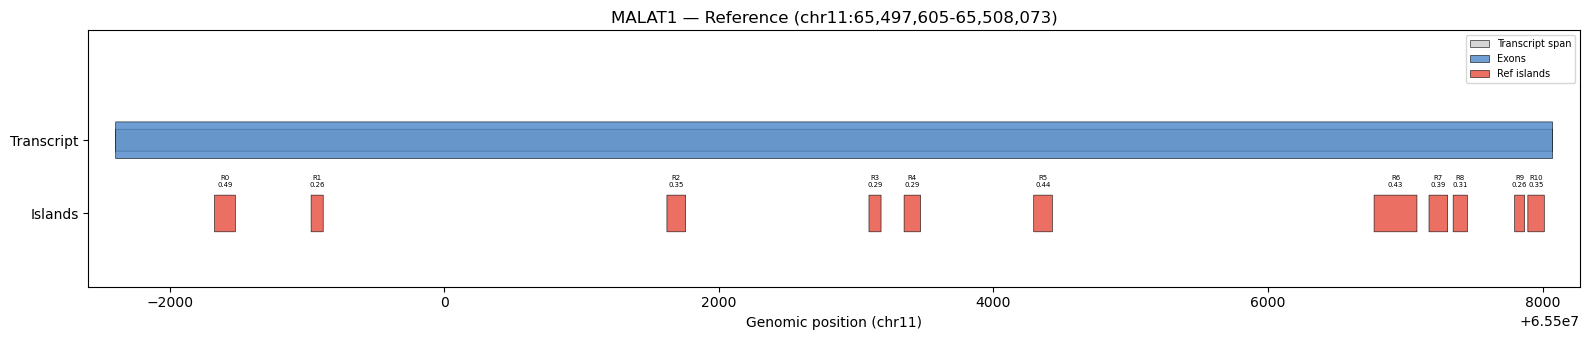

In [11]:
def plot_intervals(ax, intervals, y, height, color, label=None, alpha=0.8, edgecolor="black"):
    """Draw rectangles for a list of (start, end) intervals."""
    for i, (s, e) in enumerate(intervals):
        ax.add_patch(mpatches.FancyBboxPatch(
            (s, y - height/2), e - s, height,
            boxstyle="round,pad=0", facecolor=color, edgecolor=edgecolor,
            alpha=alpha, linewidth=0.5,
            label=label if i == 0 else None,
        ))

def add_labels(ax, intervals, y, labels, fontsize=6):
    """Add centered labels above intervals."""
    for (s, e), lbl in zip(intervals, labels):
        ax.text((s + e) / 2, y + 0.35, lbl, ha="center", va="bottom", fontsize=fontsize)


# ---- Reference side ----
fig, ax = plt.subplots(figsize=(16, 3.5))

ri_intervals = [(isl["start"], isl["end"]) for isl in ref_islands]
ri_labels = [f"R{i}\n{isl.get('score', 0):.2f}" for i, isl in enumerate(ref_islands)]

# Transcript span
plot_intervals(ax, [(ref_start, ref_end)], y=2, height=0.3, color="#cccccc", label="Transcript span")
# Exon blocks
plot_intervals(ax, ref_blocks, y=2, height=0.5, color="#4a86c8", label="Exons")
# Reference islands
plot_intervals(ax, ri_intervals, y=1, height=0.5, color="#e74c3c", label="Ref islands")
add_labels(ax, ri_intervals, y=1, labels=ri_labels, fontsize=5)

ax.set_xlim(ref_start - 200, ref_end + 200)
ax.set_ylim(0, 3.5)
ax.set_yticks([1, 2])
ax.set_yticklabels(["Islands", "Transcript"])
ax.set_xlabel(f"Genomic position ({ref_chrom})")
ax.set_title(f"{GENE_NAME} — Reference ({ref_chrom}:{ref_start:,}-{ref_end:,})")
ax.legend(loc="upper right", fontsize=7)
ax.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

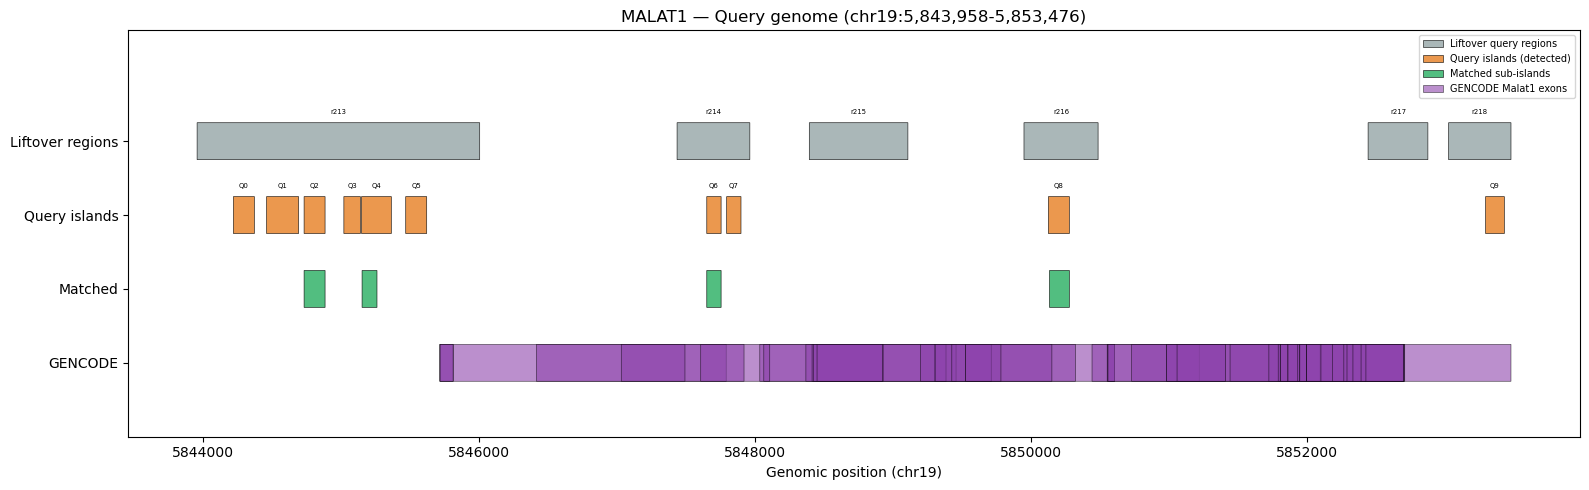

In [12]:
# ---- Query side ----
if not qr_df.empty and not qi_df.empty:
    q_global_start = qr_df["start"].min()
    q_global_end = qr_df["end"].max()
    q_chrom = qr_df["chrom"].iloc[0]

    fig, ax = plt.subplots(figsize=(16, 5))

    # Track 1: Query merged regions (liftover targets)
    qr_intervals = list(zip(qr_df["start"], qr_df["end"]))
    plot_intervals(ax, qr_intervals, y=4, height=0.5, color="#95a5a6", label="Liftover query regions")
    for _, r in qr_df.iterrows():
        ax.text((r["start"] + r["end"]) / 2, 4.35, r["cluster_id"].replace("query_merged_region_", "r"),
                ha="center", va="bottom", fontsize=5)

    # Track 2: Query islands (detected)
    qi_intervals = list(zip(qi_df["start"], qi_df["end"]))
    qi_labels_list = qi_df["label"].tolist()
    plot_intervals(ax, qi_intervals, y=3, height=0.5, color="#e67e22", label="Query islands (detected)")
    add_labels(ax, qi_intervals, y=3, labels=qi_labels_list, fontsize=5)

    # Track 3: Aligned sub-islands (final matches)
    if aligned_query_t is not None:
        aligned_blocks = aligned_query_t.blocks.tolist()
        plot_intervals(ax, [(s, e) for s, e in aligned_blocks], y=2,
                       height=0.5, color="#27ae60", label="Matched sub-islands")

    # Track 4: Mouse GENCODE exons (if available, within the query region)
    if not mt_df.empty:
        gencode_exons = []
        for _, mrow in mt_df.iterrows():
            for bs, be in mrow["blocks"]:
                if be >= q_global_start and bs <= q_global_end:
                    gencode_exons.append((max(bs, q_global_start), min(be, q_global_end)))
        if gencode_exons:
            gencode_exons = sorted(set(gencode_exons))
            plot_intervals(ax, gencode_exons, y=1, height=0.5, color="#8e44ad",
                           label=f"GENCODE {mouse_gene_name} exons", alpha=0.6)

    ax.set_xlim(q_global_start - 500, q_global_end + 500)
    ax.set_ylim(0, 5.5)
    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels(["GENCODE", "Matched", "Query islands", "Liftover regions"])
    ax.set_xlabel(f"Genomic position ({q_chrom})")
    ax.set_title(f"{GENE_NAME} — Query genome ({q_chrom}:{q_global_start:,}-{q_global_end:,})")
    ax.legend(loc="upper right", fontsize=7)
    ax.ticklabel_format(style="plain", axis="x")
    plt.tight_layout()
    plt.show()
else:
    print("No query data to plot.")

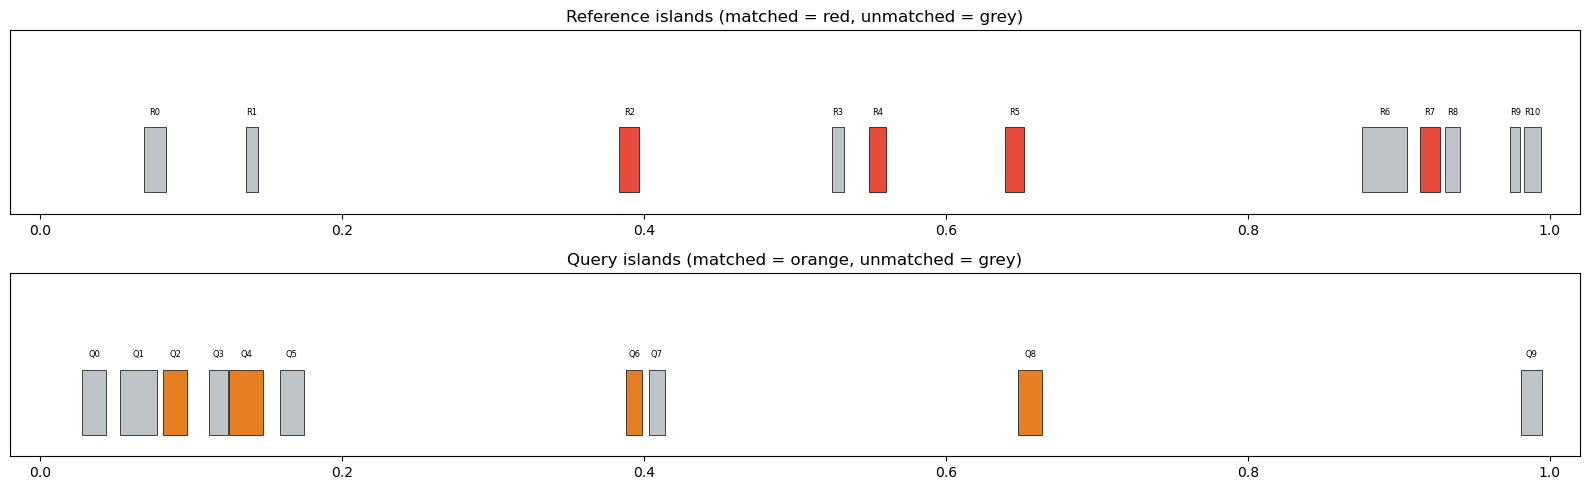


Matching pairs:
  R2 (136 bp) <-> Q2 (152 bp)  type=anchor  MMD=0.0000  chains=4
  R4 (120 bp) <-> Q4 (216 bp)  type=anchor  MMD=0.0536  chains=3
  R5 (136 bp) <-> Q6 (104 bp)  type=anchor  MMD=0.0000  chains=2
  R7 (136 bp) <-> Q8 (152 bp)  type=anchor  MMD=0.0000  chains=3


In [13]:
# ---- Matching diagram: ref islands <-> query islands ----
if not gene_align.empty:
    fig, (ax_ref, ax_q) = plt.subplots(2, 1, figsize=(16, 5), sharex=False)

    # Normalise both to 0-1 for visual comparison
    ref_span = ref_end - ref_start
    q_span = q_global_end - q_global_start if not qr_df.empty else 1

    # Reference track
    for i, isl in enumerate(ref_islands):
        s_norm = (isl["start"] - ref_start) / ref_span
        w_norm = (isl["end"] - isl["start"]) / ref_span
        matched = any((gene_align["ref_island"] == f"R{i}").values)
        color = "#e74c3c" if matched else "#bdc3c7"
        ax_ref.barh(0, w_norm, left=s_norm, height=0.6, color=color, edgecolor="black", linewidth=0.5)
        ax_ref.text(s_norm + w_norm/2, 0.4, f"R{i}", ha="center", va="bottom", fontsize=6)

    ax_ref.set_xlim(-0.02, 1.02)
    ax_ref.set_ylim(-0.5, 1.2)
    ax_ref.set_yticks([])
    ax_ref.set_title(f"Reference islands (matched = red, unmatched = grey)")

    # Query track
    if not qi_df.empty:
        for _, qi_row in qi_df.iterrows():
            s_norm = (qi_row["start"] - q_global_start) / q_span
            w_norm = qi_row["length"] / q_span
            idx_str = qi_row["label"]
            matched = any((gene_align["query_island"] == idx_str).values)
            color = "#e67e22" if matched else "#bdc3c7"
            ax_q.barh(0, w_norm, left=s_norm, height=0.6, color=color, edgecolor="black", linewidth=0.5)
            ax_q.text(s_norm + w_norm/2, 0.4, idx_str, ha="center", va="bottom", fontsize=6)

    ax_q.set_xlim(-0.02, 1.02)
    ax_q.set_ylim(-0.5, 1.2)
    ax_q.set_yticks([])
    ax_q.set_title(f"Query islands (matched = orange, unmatched = grey)")

    plt.tight_layout()
    plt.show()

    # Print matching pairs summary
    print("\nMatching pairs:")
    for _, row in gene_align.iterrows():
        r_len = int(row["ref_len"])
        q_len = int(row["query_len"])
        print(f"  {row['ref_island']} ({r_len} bp) <-> {row['query_island']} ({q_len} bp)  "
              f"type={row['type']}  MMD={row['diag_mmd']:.4f}  chains={int(row['n_chains'])}")

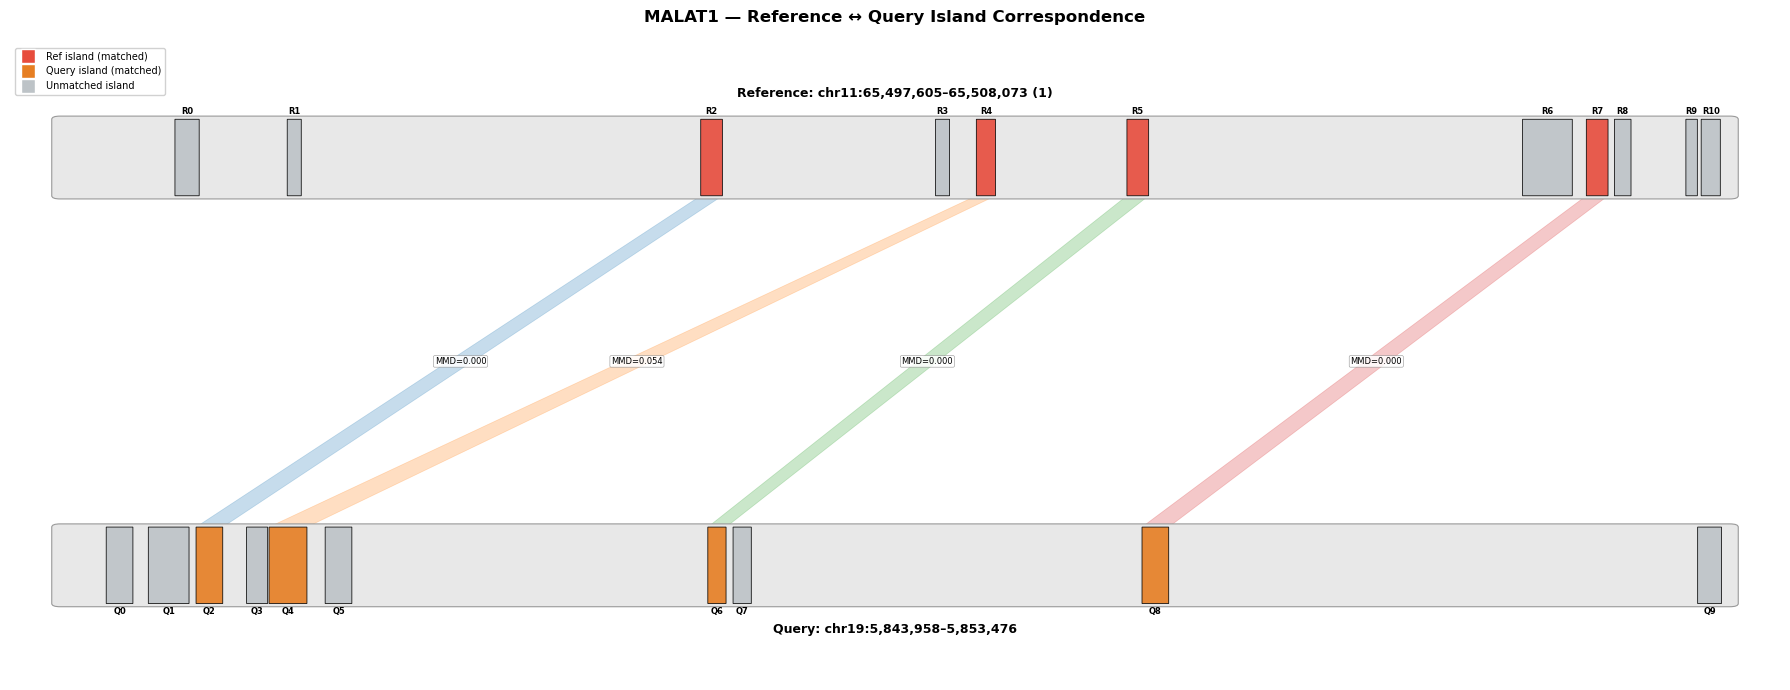

In [14]:
# ---- Correspondence map: ref islands ↔ query islands with connecting bands ----
if not gene_align.empty and not qi_df.empty and ref_islands:
    from matplotlib.patches import FancyBboxPatch, Polygon

    ref_span = ref_end - ref_start
    q_span = q_global_end - q_global_start

    # Layout constants
    REF_Y = 0.82          # top track (reference)
    Q_Y   = 0.18          # bottom track (query)
    BAR_H = 0.12          # bar height
    TRACK_PAD = 0.02      # padding inside axes

    fig, ax = plt.subplots(figsize=(18, 7))
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(0, 1)
    ax.set_axis_off()

    # --- Draw reference transcript span ---
    ax.add_patch(FancyBboxPatch(
        (0, REF_Y - BAR_H/2), 1, BAR_H,
        boxstyle="round,pad=0.005", facecolor="#e8e8e8", edgecolor="#999999",
        linewidth=0.8, zorder=1,
    ))
    ax.text(0.5, REF_Y + BAR_H/2 + 0.03,
            f"Reference: {ref_chrom}:{ref_start:,}–{ref_end:,} ({ref_strand})",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

    # --- Draw reference islands ---
    # Build a set of matched ref indices for coloring
    matched_ref_set = set()
    for _, row in gene_align.iterrows():
        ri_str = row["ref_island"]  # e.g. "R2"
        matched_ref_set.add(int(ri_str[1:]))

    for i, isl in enumerate(ref_islands):
        x0 = (isl["start"] - ref_start) / ref_span
        w = (isl["end"] - isl["start"]) / ref_span
        matched = i in matched_ref_set
        color = "#e74c3c" if matched else "#bdc3c7"
        ax.add_patch(FancyBboxPatch(
            (x0, REF_Y - BAR_H/2), w, BAR_H,
            boxstyle="round,pad=0", facecolor=color, edgecolor="black",
            linewidth=0.6, alpha=0.9, zorder=2,
        ))
        ax.text(x0 + w/2, REF_Y + BAR_H/2 + 0.005, f"R{i}",
                ha="center", va="bottom", fontsize=6, fontweight="bold")

    # --- Draw query locus span ---
    ax.add_patch(FancyBboxPatch(
        (0, Q_Y - BAR_H/2), 1, BAR_H,
        boxstyle="round,pad=0.005", facecolor="#e8e8e8", edgecolor="#999999",
        linewidth=0.8, zorder=1,
    ))
    ax.text(0.5, Q_Y - BAR_H/2 - 0.03,
            f"Query: {q_chrom}:{q_global_start:,}–{q_global_end:,}",
            ha="center", va="top", fontsize=9, fontweight="bold")

    # --- Draw query islands ---
    matched_q_set = set()
    for _, row in gene_align.iterrows():
        qi_str = row["query_island"]
        matched_q_set.add(qi_str)

    for _, qi_row in qi_df.iterrows():
        x0 = (qi_row["start"] - q_global_start) / q_span
        w = qi_row["length"] / q_span
        idx_str = qi_row["label"].split(" ")[0]
        matched = idx_str in matched_q_set
        color = "#e67e22" if matched else "#bdc3c7"
        ax.add_patch(FancyBboxPatch(
            (x0, Q_Y - BAR_H/2), w, BAR_H,
            boxstyle="round,pad=0", facecolor=color, edgecolor="black",
            linewidth=0.6, alpha=0.9, zorder=2,
        ))
        ax.text(x0 + w/2, Q_Y - BAR_H/2 - 0.005, idx_str,
                ha="center", va="top", fontsize=6, fontweight="bold")

    # --- Draw connecting bands between matched pairs ---
    band_colors = plt.cm.tab10.colors
    for pair_idx, (_, row) in enumerate(gene_align.iterrows()):
        ri_idx = int(row["ref_island"][1:])
        ri_isl = ref_islands[ri_idx]

        # Ref island normalised coords
        r_x0 = (ri_isl["start"] - ref_start) / ref_span
        r_x1 = (ri_isl["end"] - ref_start) / ref_span

        # Find matching query island coords
        qi_str = row["query_island"]
        qi_match = qi_df[qi_df["label"] == qi_str]
        if qi_match.empty:
            continue
        qi_row = qi_match.iloc[0]
        q_x0 = (qi_row["start"] - q_global_start) / q_span
        q_x1 = (qi_row["start"] + qi_row["length"] - q_global_start) / q_span

        band_color = band_colors[pair_idx % len(band_colors)]

        # Draw a polygon connecting the bottom edge of ref island to top edge of query island
        polygon = Polygon(
            [
                (r_x0, REF_Y - BAR_H/2),
                (r_x1, REF_Y - BAR_H/2),
                (q_x1, Q_Y + BAR_H/2),
                (q_x0, Q_Y + BAR_H/2),
            ],
            closed=True,
            facecolor=band_color,
            edgecolor=band_color,
            alpha=0.25,
            linewidth=0.5,
            zorder=0,
        )
        ax.add_patch(polygon)

        # Label in the middle of the band
        mid_x = (r_x0 + r_x1 + q_x0 + q_x1) / 4
        mid_y = (REF_Y + Q_Y) / 2
        mmd_val = float(row["diag_mmd"])
        ax.text(mid_x, mid_y, f"MMD={mmd_val:.3f}",
                ha="center", va="center", fontsize=6,
                bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="gray",
                          alpha=0.85, linewidth=0.4))

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker="s", color="w", markerfacecolor="#e74c3c",
               markersize=10, label="Ref island (matched)"),
        Line2D([0], [0], marker="s", color="w", markerfacecolor="#e67e22",
               markersize=10, label="Query island (matched)"),
        Line2D([0], [0], marker="s", color="w", markerfacecolor="#bdc3c7",
               markersize=10, label="Unmatched island"),
    ]
    ax.legend(handles=legend_elements, loc="upper left", fontsize=7, framealpha=0.9)

    ax.set_title(f"{GENE_NAME} — Reference ↔ Query Island Correspondence",
                 fontsize=12, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to plot correspondence map.")

---
## Summary

In [15]:
print(f"{'='*60}")
print(f" Pipeline Diagnostic Summary: {GENE_NAME} ({GENE_ID})")
print(f"{'='*60}")
print(f"")
print(f"Reference:")
print(f"  Location:        {ref_chrom}:{ref_start:,}-{ref_end:,} ({ref_strand})")
print(f"  Exonic bp:       {ref_exonic_bp:,}")
print(f"  Islands found:   {len(ref_islands)}")
if ref_islands:
    ri_total = sum(isl['end'] - isl['start'] for isl in ref_islands)
    print(f"  Island coverage: {ri_total:,} bp ({100*ri_total/ref_exonic_bp:.1f}%)")
print()
print(f"Liftover:")
print(f"  Query regions:   {len(query_region_ids)}")
if not qr_df.empty:
    print(f"  Query span:      {q_chrom}:{qr_df['start'].min():,}-{qr_df['end'].max():,}")
print()
print(f"Query islands:")
print(f"  Islands found:   {len(qi_df)}")
if not qi_df.empty:
    print(f"  Total coverage:  {qi_df['length'].sum():,} bp")
print()
print(f"Island matching:")
print(f"  Matched pairs:   {len(gene_align)}")
if not gene_align.empty:
    print(f"  Anchors:         {(gene_align['type'] == 'anchor').sum()}")
    print(f"  Fills:           {(gene_align['type'] == 'fill').sum()}")
    print(f"  Median MMD:      {gene_align['diag_mmd'].median():.4f}")
    print(f"  Mean MMD:        {gene_align['diag_mmd'].mean():.4f}")
print()
print(f"GENCODE validation:")
print(f"  Mouse transcripts: {len(mt_df)}")
if aligned_query_t is not None and not mt_df.empty:
    best_ov = ov_df.iloc[0]
    print(f"  Best overlap:    {int(best_ov['overlap_bp']):,} bp "
          f"({best_ov['overlap_pct_of_pred']:.1f}% of predicted) "
          f"with {best_ov['transcript_id']}")

 Pipeline Diagnostic Summary: MALAT1 (U_ENSG00000251562)

Reference:
  Location:        chr11:65,497,605-65,508,073 (1)
  Exonic bp:       10,468
  Islands found:   11
  Island coverage: 1,464 bp (14.0%)

Liftover:
  Query regions:   6
  Query span:      chr19:5,843,958-5,853,476

Query islands:
  Islands found:   10
  Total coverage:  1,520 bp

Island matching:
  Matched pairs:   4
  Anchors:         4
  Fills:           0
  Median MMD:      0.0000
  Mean MMD:        0.0134

GENCODE validation:
  Mouse transcripts: 23
  Best overlap:    248 bp (48.8% of predicted) with ENSMUST00000172812.5
